<a href="https://www.kaggle.com/code/mosairulalamtyhan/ford-car-price-prediction?scriptVersionId=319518863" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r'/kaggle/input/datasets/adhurimquku/ford-car-price-prediction/ford.csv')

In [3]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [4]:
df.shape

(17966, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [6]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [7]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(154)

# EDA

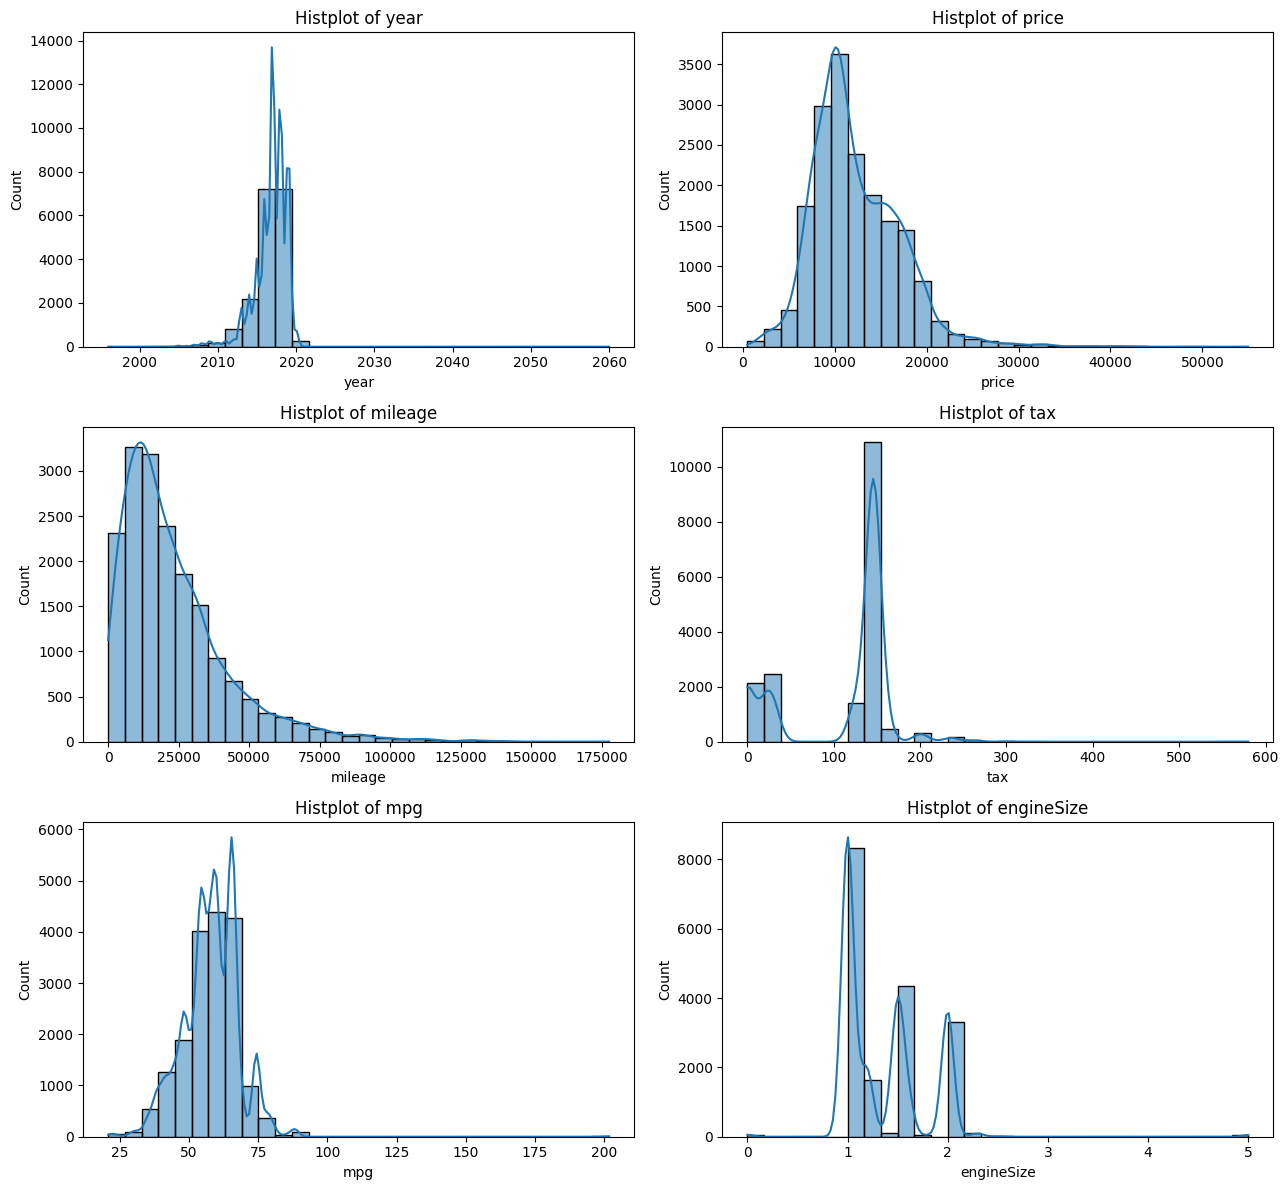

In [9]:
cols = ['year','price','mileage','tax','mpg','engineSize']


plt.figure(figsize=(13,12))

for i,col in enumerate(cols):
    plt.subplot(3,2,1+i)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Histplot of {col}")

plt.tight_layout()
plt.show()

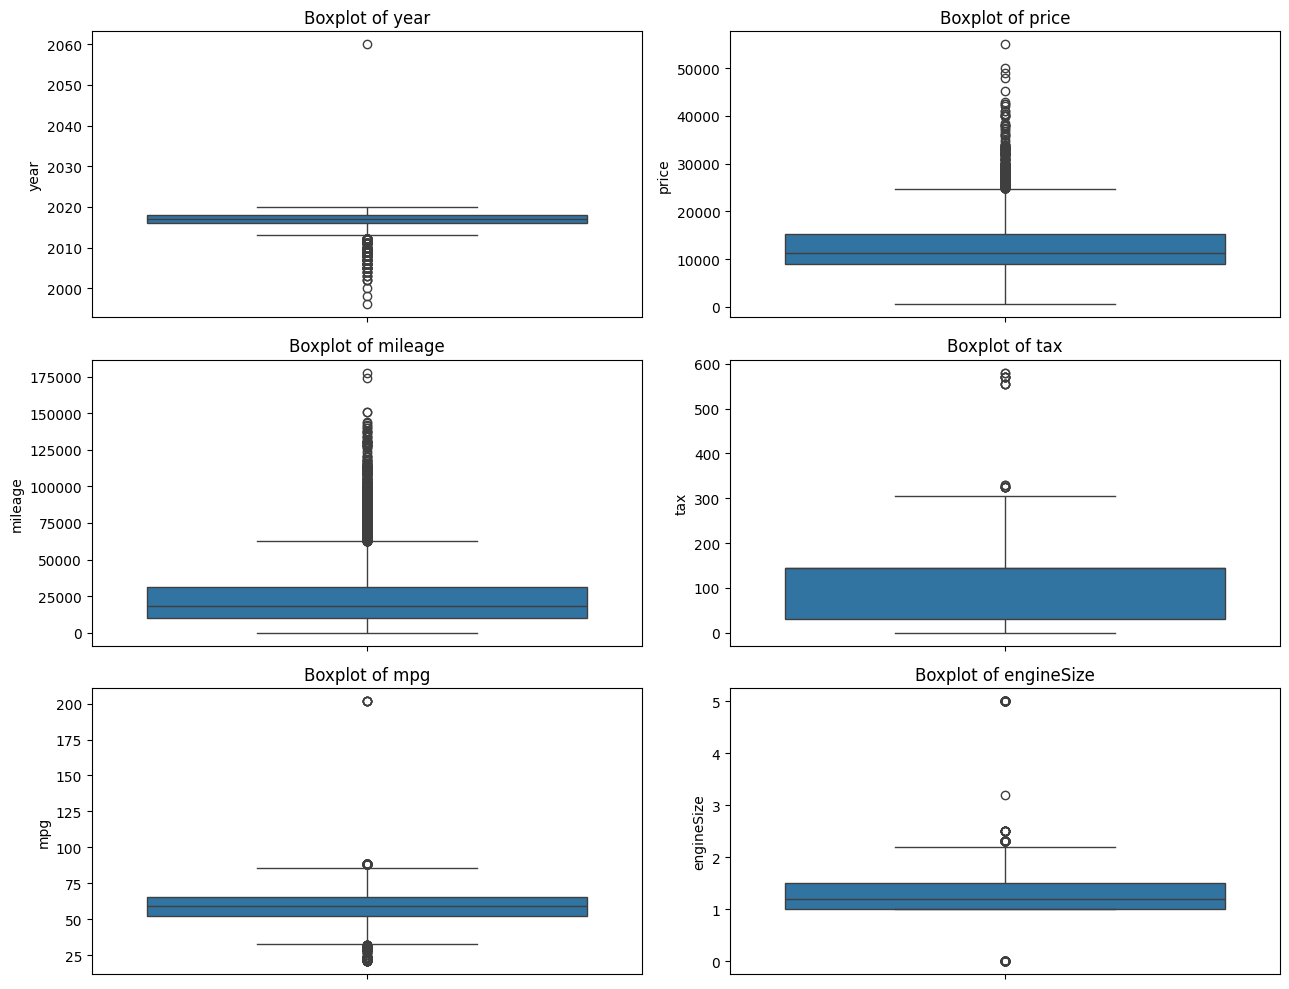

In [10]:
cols = ['year','price','mileage','tax','mpg','engineSize']


plt.figure(figsize=(13,10))

for i,col in enumerate(cols):
    plt.subplot(3,2,1+i)
    sns.boxplot(df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

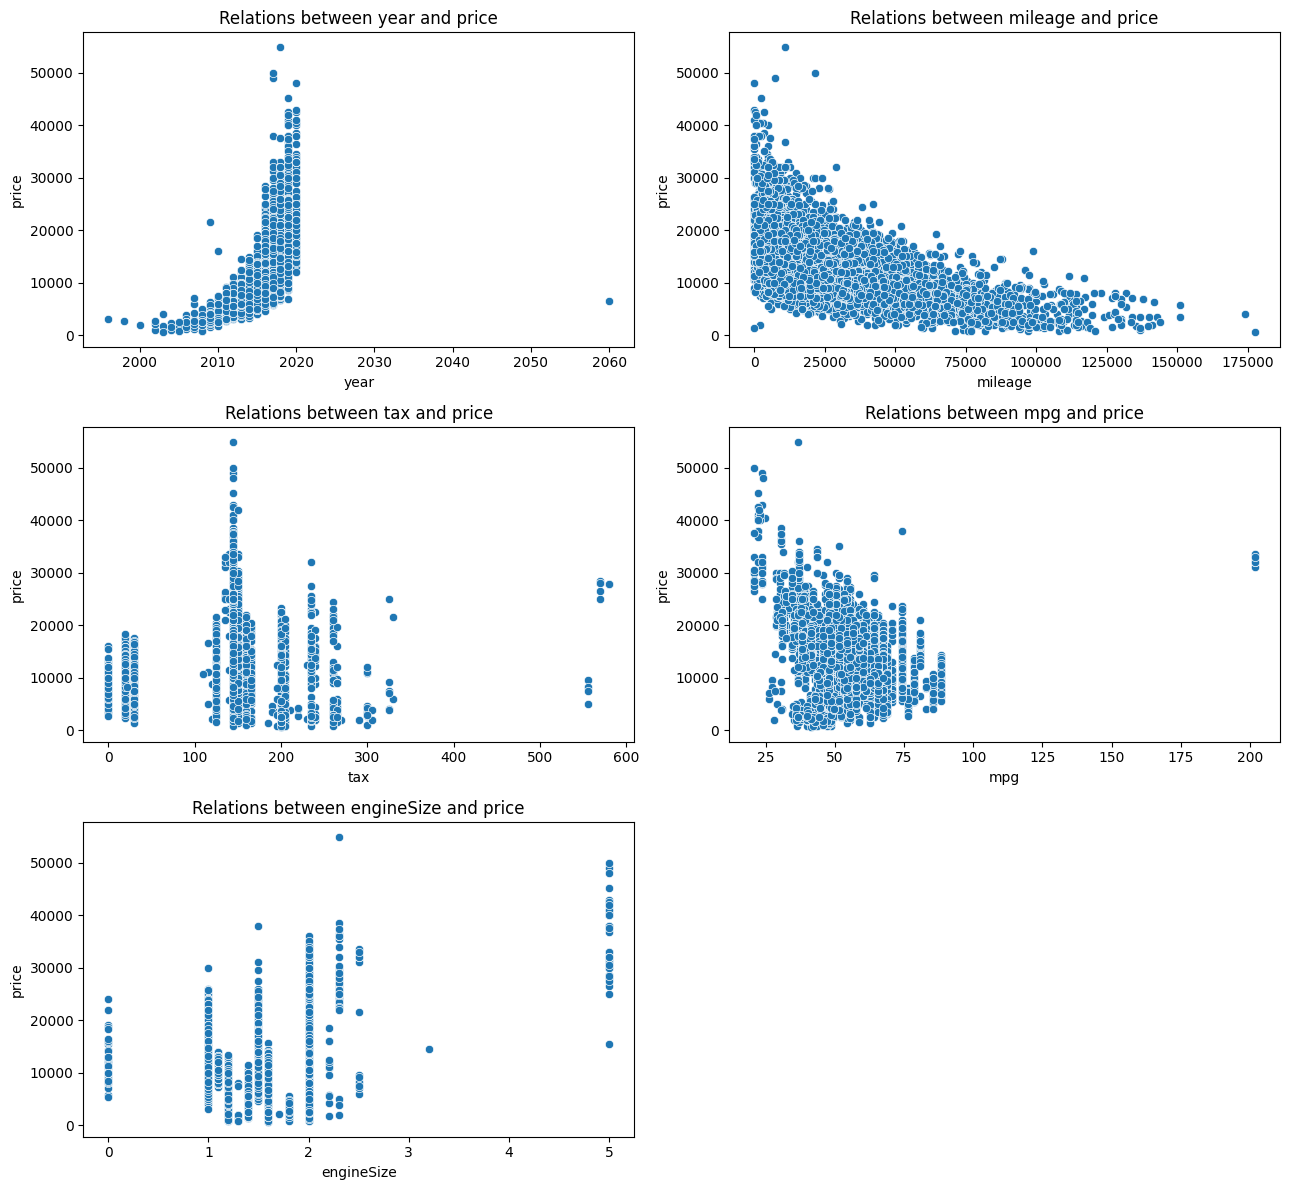

In [11]:
cols = ['year','mileage','tax','mpg','engineSize']


plt.figure(figsize=(13,12))

for i,col in enumerate(cols):
    plt.subplot(3,2,1+i)
    sns.scatterplot(data=df, x=col, y=df['price'])
    plt.title(f"Relations between {col} and price")

plt.tight_layout()
plt.show()

In [12]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

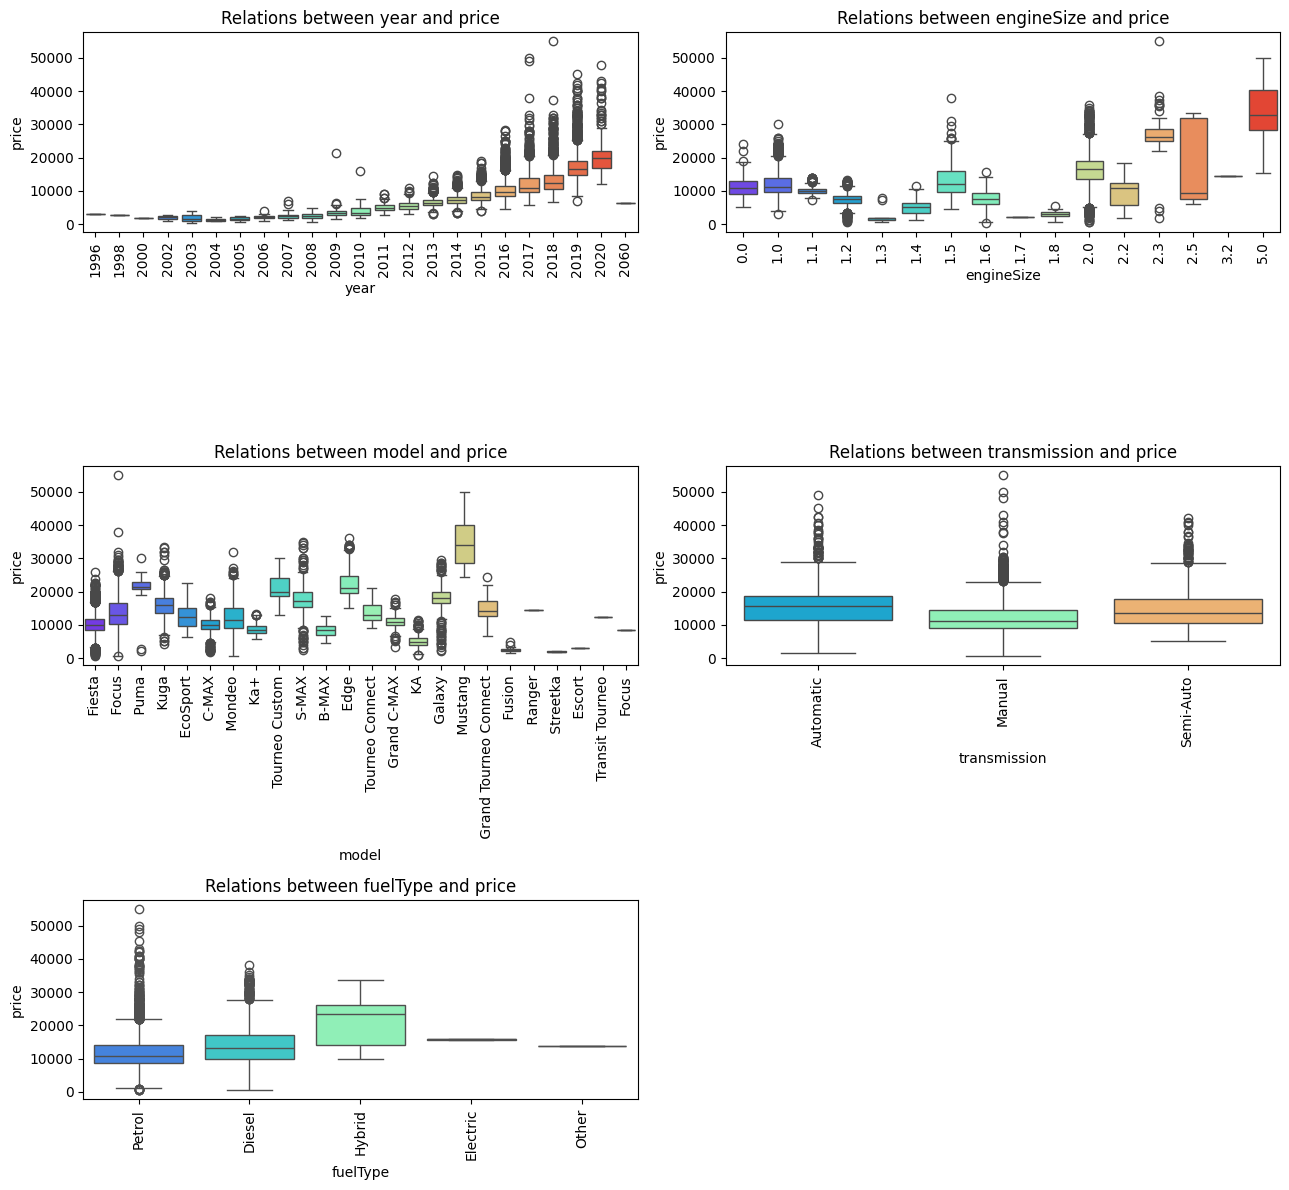

In [13]:
cols = ['year','engineSize','model','transmission','fuelType']


plt.figure(figsize=(13,12))

for i,col in enumerate(cols):
    plt.subplot(3,2,1+i)
    sns.boxplot(data= df, x = col, y=df['price'], palette='rainbow')
    plt.title(f"Relations between {col} and price")
    plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

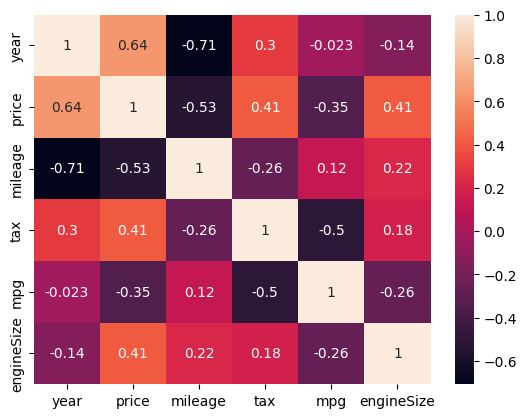

In [14]:
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True)
plt.show()

# Data Cleaning and Preprocessing

In [15]:
print(f'Before deleting duplicates: {df.shape[0]}')

df.drop_duplicates(inplace=True)

print(f'After deleting duplicates: {df.shape[0]}')

Before deleting duplicates: 17966
After deleting duplicates: 17812


In [16]:
mode_year = df['year'].mode()[0]

df['year'] = df['year'].replace(2060, mode_year)

In [17]:
X = df.drop('price', axis=1)
y = df['price']

**One-Hot-Encoding**

In [18]:
X_ohe = pd.get_dummies(
    data = X,
    columns=['model','transmission','fuelType'],
    drop_first= True
).astype(int)


**Label-Encoding**

In [19]:
encoder = LabelEncoder()

cols = ['model','transmission','fuelType']
X_label = X.copy()

for col in cols:
    X_label[col] = encoder.fit_transform(df[col])

**Scaling One-Hot-Encoding & Label-Encoding Data**

In [20]:
scaler = StandardScaler()

cols = ['year','mileage','tax','mpg','engineSize']
X_ohe_ss = X_ohe.copy()
X_label_ss = X_label.copy()

X_ohe_ss[cols] = scaler.fit_transform(X_ohe_ss[cols])

X_label_ss = pd.DataFrame(
    data = scaler.fit_transform(X_label_ss),
    columns=X_label_ss.columns
)

# Feature Selection

**Features Importances In Label-Encodig Data**

In [21]:
model = RandomForestRegressor(random_state=42)
model.fit(X_label, y)

importance = model.feature_importances_.round(2)*100

for col,imp in zip(X_label.columns, importance):
    print(f"{col}:{imp}%")

model:10.0%
year:49.0%
transmission:1.0%
mileage:8.0%
fuelType:0.0%
tax:1.0%
mpg:7.000000000000001%
engineSize:24.0%


**Features Importances In One-Hot-Encodig Data**

In [22]:
model = RandomForestRegressor(random_state=42)
model.fit(X_ohe, y)

importance = model.feature_importances_.round(2)*100

for col,imp in zip(X_ohe.columns, importance):
    print(f"{col} : {imp}%")

year : 49.0%
mileage : 7.000000000000001%
tax : 1.0%
mpg : 7.000000000000001%
engineSize : 22.0%
model_ C-MAX : 0.0%
model_ EcoSport : 0.0%
model_ Edge : 1.0%
model_ Escort : 0.0%
model_ Fiesta : 2.0%
model_ Focus : 1.0%
model_ Fusion : 0.0%
model_ Galaxy : 0.0%
model_ Grand C-MAX : 0.0%
model_ Grand Tourneo Connect : 0.0%
model_ KA : 0.0%
model_ Ka+ : 2.0%
model_ Kuga : 3.0%
model_ Mondeo : 0.0%
model_ Mustang : 2.0%
model_ Puma : 0.0%
model_ Ranger : 0.0%
model_ S-MAX : 0.0%
model_ Streetka : 0.0%
model_ Tourneo Connect : 0.0%
model_ Tourneo Custom : 0.0%
model_ Transit Tourneo : 0.0%
model_Focus : 0.0%
transmission_Manual : 1.0%
transmission_Semi-Auto : 0.0%
fuelType_Electric : 0.0%
fuelType_Hybrid : 0.0%
fuelType_Other : 0.0%
fuelType_Petrol : 0.0%


# Cross Validation

 **In One-Hot-Encoding Data**

In [23]:
model = LinearRegression()
model_2 = SVR()
model_3 = DecisionTreeRegressor()
model_4 = RandomForestRegressor()
model_5 = XGBRegressor()

models = {
    'lr':model,
    'svr':model_2,
    'dt':model_3,
    'rf':model_4,
    'xgb':model_5
}

for name,model in models.items():
    scores = cross_val_score(model, X_ohe, y, cv=5)
    
    print(f'----------{name}---------')
    
    print(f'All Score: {scores}')
    print(f'Average Score: {scores.mean()}')
    print('-'*30)

----------lr---------
All Score: [0.85482365 0.83820412 0.84637102 0.82921811 0.7694605 ]
Average Score: 0.8276154808614367
------------------------------
----------svr---------
All Score: [ 0.10085673  0.09835542  0.00071503 -0.03850506  0.13276048]
Average Score: 0.05883652004421926
------------------------------
----------dt---------
All Score: [0.87011417 0.88695666 0.88091272 0.87283098 0.87579794]
Average Score: 0.8773224915305147
------------------------------
----------rf---------
All Score: [0.91678773 0.92353103 0.9197131  0.91348771 0.91606148]
Average Score: 0.9179162108521357
------------------------------
----------xgb---------
All Score: [0.92803514 0.9355126  0.93114471 0.91959089 0.93179023]
Average Score: 0.9292147159576416
------------------------------


**In Label-Data**

In [25]:
model = LinearRegression()
model_2 = SVR()
model_3 = DecisionTreeRegressor()
model_4 = RandomForestRegressor()
model_5 = XGBRegressor()

models = {
    'lr':model,
    'svr':model_2,
    'dt':model_3,
    'rf':model_4,
    'xgb':model_5
}

for name,model in models.items():
    scores = cross_val_score(model, X_label, y, cv=5)
    
    print(f'----------{name}---------')
    
    print(f'All Score: {scores}')
    print(f'Average Score: {scores.mean()}')
    print('-'*30)

----------lr---------
All Score: [0.72160032 0.71621595 0.73014592 0.73158943 0.6739602 ]
Average Score: 0.7147023647768835
------------------------------
----------svr---------
All Score: [ 0.10176115  0.09966964  0.0022615  -0.0377619   0.13228681]
Average Score: 0.05964343959428671
------------------------------
----------dt---------
All Score: [0.87742218 0.88582572 0.88174637 0.87997399 0.86608628]
Average Score: 0.8782109096887474
------------------------------
----------rf---------
All Score: [0.91792318 0.92791867 0.92073063 0.91581633 0.91602053]
Average Score: 0.9196818687616887
------------------------------
----------xgb---------
All Score: [0.92918152 0.93999827 0.93309581 0.9234277  0.93102837]
Average Score: 0.931346333026886
------------------------------


In [26]:
X_train, X_test, y_train, y_test = train_test_split(X_ohe, y, test_size=0.2, random_state=42)

In [47]:
model = XGBRegressor(
    subsample= 0.6,
    n_estimators= 60,
    max_leaves= 14,
    max_depth= 19,
    learning_rate= 0.2,
    colsample_bytree= 1.0
)

model.fit(X_train, y_train)

model.score(X_train, y_train),model.score(X_test, y_test)

(0.9294005632400513, 0.921488344669342)

In [48]:
params = {
    'max_depth': [n for n in range(1, 20)],
    'max_leaves': [n for n in range(1, 40)],
    'n_estimators': [n for n in range(50, 200, 5)],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]
}

In [49]:
random_search = RandomizedSearchCV(
    model,
    param_distributions= params,
    cv = 5,
    scoring= 'accuracy',
    random_state= 42
)

random_search.fit(X_train, y_train)

print('Best Params:', random_search.best_params_)
print('Best Score:', random_search.best_score_)

Best Params: {'subsample': 0.6, 'n_estimators': 60, 'max_leaves': 14, 'max_depth': 19, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
Best Score: nan


# Model Evaluation

In [50]:
y_pred = model.predict(X_test)

In [51]:
r2 = r2_score(y_test, y_pred)
n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))

print(f"R2:", r2)
print(f"Adjusted R2: {adjusted_r2}")
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}')


R2: 0.921488344669342
Adjusted R2: 0.9207317130703504
MAE: 949.859130859375
MSE: 1760471.125
RMSE: 1326.8274661763676


In [ ]:
import joblib

joblib.dump(model, 'Ford_Car_Price_Prediction.pkl')